# Utilizando prophet para a análise preditíva dos dados

🔄 Passo 1: Carregando e limpando os dados...


16:52:00 - cmdstanpy - INFO - Chain [1] start processing


Iniciando a Inteligência Artificial com Prophet...

Treinando o modelo com o histórico de vendas (Isso pode levar alguns segundos)...


16:52:00 - cmdstanpy - INFO - Chain [1] done processing


📈 Gerando o gráfico de previsão...


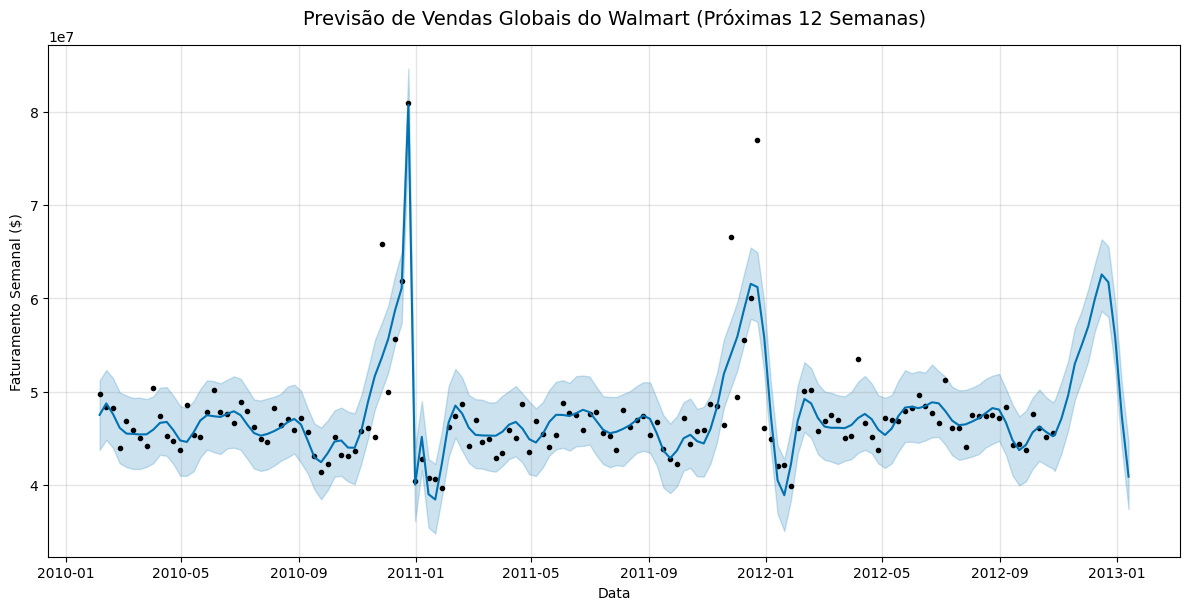


✅ Sucesso! O arquivo 'walmart_previsao_looker.csv' foi gerado na sua pasta e está pronto para o Looker.


In [7]:
import kagglehub
import pandas as pd
import os
from prophet import Prophet
import matplotlib.pyplot as plt

print("🔄 Passo 1: Carregando e limpando os dados...")

# Localizar e ler o arquivo baixado
path = kagglehub.dataset_download("michaelhakim/walmart-sales-analysis")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)

# Aplicar a limpeza que validamos na etapa de EDA
df.columns = df.columns.str.strip()
df['Weekly_Sales'] = df['Weekly_Sales'].astype(str).str.replace(r'[$,]', '', regex=True).astype(float)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')


print("Iniciando a Inteligência Artificial com Prophet...\n")

# 1. Preparar os dados para o Prophet (Global)
df_global = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
df_global = df_global.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

# 2. Configurar o Modelo (Adicionando os feriados americanos)
modelo = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo.add_country_holidays(country_name='US')

# 3. Treinar o modelo com o nosso histórico
print("Treinando o modelo com o histórico de vendas (Isso pode levar alguns segundos)...")
modelo.fit(df_global)

# 4. Criar o calendário do futuro (Prever as próximas 12 semanas)
futuro = modelo.make_future_dataframe(periods=12, freq='W')

# 5. Fazer a previsão matemática
previsao = modelo.predict(futuro)

# 6. Plotar o gráfico gerado pela IA
print("📈 Gerando o gráfico de previsão...")
fig1 = modelo.plot(previsao, figsize=(12, 6))
plt.title('Previsão de Vendas Globais do Walmart (Próximas 12 Semanas)', fontsize=14, pad=15)
plt.xlabel('Data')
plt.ylabel('Faturamento Semanal ($)')
plt.show()

# 7. Preparar e exportar o arquivo FINAL para o Looker Studio
df_looker = previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
df_looker = df_looker.rename(columns={
    'ds': 'Date',
    'yhat': 'Previsao_Vendas',
    'yhat_lower': 'Cenario_Pessimista',
    'yhat_upper': 'Cenario_Otimista'
})

df_looker['Date'] = df_looker['Date'].dt.strftime('%Y-%m-%d')
df_looker.to_csv('C:\\Users\\mateu\\Arquivos de Programas Faculdade\\repositorios\\Sales-Prediction-Data-Modeling-For-Google-Locker_Dashboard\\data\\processed\\walmart_previsao_looker.csv', index=False)

print("\n✅ Sucesso! O arquivo 'walmart_previsao_looker.csv' foi gerado na sua pasta e está pronto para o Looker.")

### Unificação do CSV e Gráfico Específico

📈 Gerando o gráfico de previsão aprimorado...


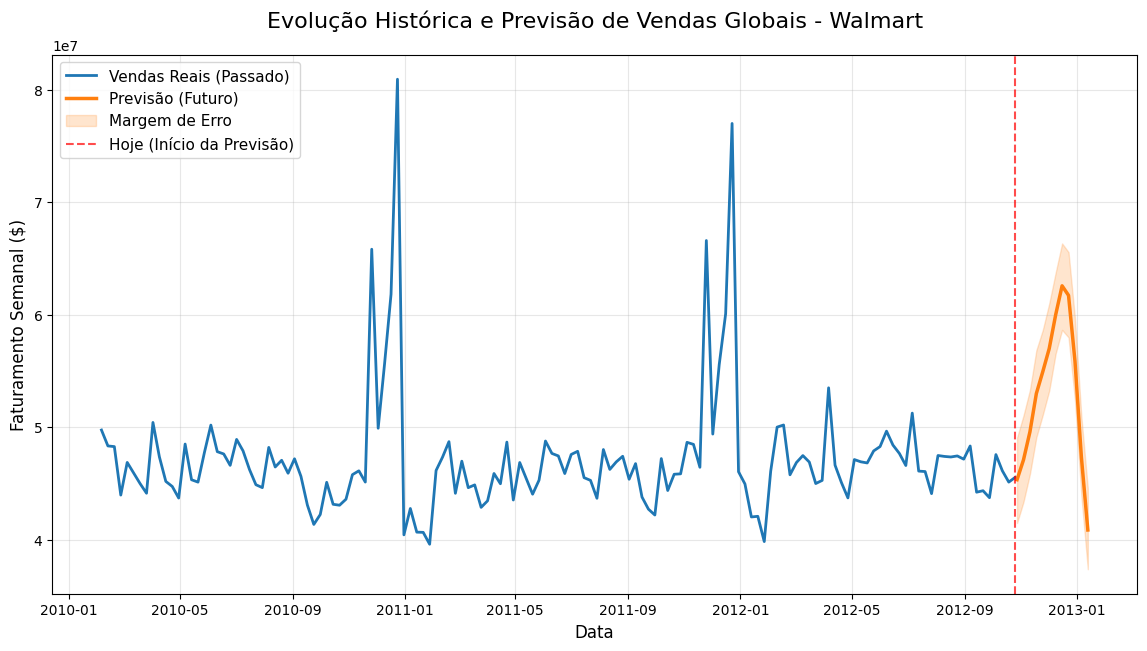

🗃️ Preparando a Tabela Unificada para o Looker Studio...

✅ SUCESSO ABSOLUTO! O arquivo 'walmart_dados_looker.csv' está pronto com todo o passado e futuro unificados.


In [8]:
print("📈 Gerando o gráfico de previsão aprimorado...")

# Descobrir qual é a última data do nosso histórico real
data_limite_historico = df_global['ds'].max()

# Separar os dados para o gráfico ficar com cores diferentes
historico_real = df_global
futuro_previsto = previsao[previsao['ds'] > data_limite_historico]

# Criar um gráfico bonito e claro
plt.figure(figsize=(14, 7))

# 1. Plotar o passado (Linha Azul)
plt.plot(historico_real['ds'], historico_real['y'], label='Vendas Reais (Passado)', color='#1f77b4', linewidth=2)

# 2. Plotar o futuro (Linha Laranja)
plt.plot(futuro_previsto['ds'], futuro_previsto['yhat'], label='Previsão (Futuro)', color='#ff7f0e', linewidth=2.5)

# 3. Adicionar a "Sombra" da margem de erro apenas no futuro
plt.fill_between(futuro_previsto['ds'], futuro_previsto['yhat_lower'], futuro_previsto['yhat_upper'], color='#ff7f0e', alpha=0.2, label='Margem de Erro')

# 4. Linha vertical vermelha para marcar a divisão de tempo
plt.axvline(x=data_limite_historico, color='red', linestyle='--', alpha=0.7, label='Hoje (Início da Previsão)')

# Configurações visuais do gráfico
plt.title('Evolução Histórica e Previsão de Vendas Globais - Walmart', fontsize=16, pad=20)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Faturamento Semanal ($)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("🗃️ Preparando a Tabela Unificada para o Looker Studio...")

# Juntar os valores reais com os previstos na mesma tabela
df_looker = previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
df_looker = df_looker.merge(df_global[['ds', 'y']], on='ds', how='left')

# Criar a coluna 'Tipo_Dado' para facilitar o filtro no Looker
df_looker['Tipo_Dado'] = 'Histórico'
df_looker.loc[df_looker['ds'] > data_limite_historico, 'Tipo_Dado'] = 'Previsão'

# Renomear as colunas para nomes amigáveis de negócios
df_looker = df_looker.rename(columns={
    'ds': 'Data',
    'y': 'Vendas_Reais',
    'yhat': 'Vendas_Previstas',
    'yhat_lower': 'Cenario_Pessimista',
    'yhat_upper': 'Cenario_Otimista'
})

# Exportar o CSV Unificado
df_looker['Data'] = df_looker['Data'].dt.strftime('%Y-%m-%d')
df_looker.to_csv('walmart_dados_looker.csv', index=False)

print("\n✅ SUCESSO ABSOLUTO! O arquivo 'walmart_dados_looker.csv' está pronto com todo o passado e futuro unificados.")

In [10]:
import kagglehub
import pandas as pd
import numpy as np
import os
from prophet import Prophet
import matplotlib.pyplot as plt

print("🔄 Passo 1: Carregando e limpando os dados...")

# Localizar e ler o arquivo baixado
path = kagglehub.dataset_download("michaelhakim/walmart-sales-analysis")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)

# Aplicar a limpeza
df.columns = df.columns.str.strip()
df['Weekly_Sales'] = df['Weekly_Sales'].astype(str).str.replace(r'[$,]', '', regex=True).astype(float)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df['Temperature'] = (df['Temperature'] - 32) * 5.0/9.0

print("🤖 Passo 2: Iniciando a Inteligência Artificial com Prophet...")

# Preparar dados para o Prophet
df_global = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
df_global = df_global.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

# Configurar e treinar o Modelo
modelo = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo.add_country_holidays(country_name='US')
modelo.fit(df_global)

# =====================================================================
# ALTERAÇÃO AQUI: Ampliando a previsão para 52 semanas (1 ano)
# =====================================================================
print("🔮 Calculando o futuro (52 semanas)...")
futuro = modelo.make_future_dataframe(periods=52, freq='W')
previsao = modelo.predict(futuro)

print("🗃️ Construindo a Base Master para o Looker Studio...")

# Preparar o Histórico (Preservando as variáveis: CPI, Temperatura, etc.)
df_historico = df.copy()
df_historico['Store_Number'] = df_historico['Store_Number'].astype(str)
df_historico['Tipo_Dado'] = 'Histórico'
df_historico['Vendas_Previstas'] = np.nan
df_historico['Cenario_Pessimista'] = np.nan
df_historico['Cenario_Otimista'] = np.nan

# Preparar o Futuro 
data_limite_historico = df['Date'].max()
futuro_previsto = previsao[previsao['ds'] > data_limite_historico].copy()

df_futuro = pd.DataFrame({
    'Store_Number': 'Previsão Global',
    'Date': futuro_previsto['ds'],
    'Weekly_Sales': np.nan, 
    'Holiday_Flag': np.nan, 
    'Temperature': np.nan,
    'Fuel_Price': np.nan,
    'CPI': np.nan,
    'Unemployment': np.nan,
    'Tipo_Dado': 'Previsão',
    'Vendas_Previstas': futuro_previsto['yhat'],
    'Cenario_Pessimista': futuro_previsto['yhat_lower'],
    'Cenario_Otimista': futuro_previsto['yhat_upper']
})

# Juntar as duas tabelas
df_master = pd.concat([df_historico, df_futuro], ignore_index=True)

# Formatar a Data para o padrão ISO (YYYY-MM-DD)
df_master['Date'] = pd.to_datetime(df_master['Date']).dt.strftime('%Y-%m-%d')

# =====================================================================
# ALTERAÇÃO AQUI: Exportando diretamente para o seu diretório processed
# =====================================================================
caminho_pasta = r"C:\Users\mateu\Arquivos de Programas Faculdade\repositorios\Sales-Prediction-Data-Modeling-For-Google-Locker_Dashboard\data\processed"

# Garante que a pasta exista antes de tentar salvar
if not os.path.exists(caminho_pasta):
    os.makedirs(caminho_pasta)

caminho_arquivo = os.path.join(caminho_pasta, 'walmart_master_looker.csv')
df_master.to_csv(caminho_arquivo, index=False)

print(f"\n✅ BASE MASTER GERADA COM SUCESSO!")
print(f"-> Salvo em: {caminho_arquivo}")
print(f"-> Linhas de Histórico: {len(df_historico)}")
print(f"-> Linhas de Previsão: {len(df_futuro)}")

🔄 Passo 1: Carregando e limpando os dados...
🤖 Passo 2: Iniciando a Inteligência Artificial com Prophet...


17:04:38 - cmdstanpy - INFO - Chain [1] start processing
17:04:39 - cmdstanpy - INFO - Chain [1] done processing


🔮 Calculando o futuro (52 semanas)...
🗃️ Construindo a Base Master para o Looker Studio...

✅ BASE MASTER GERADA COM SUCESSO!
-> Salvo em: C:\Users\mateu\Arquivos de Programas Faculdade\repositorios\Sales-Prediction-Data-Modeling-For-Google-Locker_Dashboard\data\processed\walmart_master_looker.csv
-> Linhas de Histórico: 6435
-> Linhas de Previsão: 52
